# Tendencia, estacionalidad y dependencia temporal

## Tópicos Selectos de Matemáticas Aplicadas II

En los notebooks anteriores trabajamos con series temporales de corta duración para estudiar:

- rezagos;
- diferencias;
- tasas de cambio;
- ventanas móviles;
- construcción de características temporales.

Ahora utilizaremos una serie diaria considerablemente más larga, correspondiente al periodo

$$
2020-01-01
\quad\text{a}\quad
2025-12-31.
$$

La variable de interés será

$$
Y_t
=
\text{concentración diaria promedio de O}_3.
$$

Disponemos de

$$
T=2192
$$

observaciones diarias, lo que permite estudiar estructuras temporales que no podían analizarse adecuadamente con una serie de solamente algunos meses.



## Componentes de una serie temporal

De manera conceptual, una serie puede representarse como la combinación de distintas componentes:

$$
Y_t
=
T_t
+
S_t
+
R_t,
$$

donde:

- $T_t$ representa la **tendencia**;
- $S_t$ representa la **estacionalidad**;
- $R_t$ representa las variaciones residuales o irregulares.

La tendencia describe cambios de largo plazo.

La estacionalidad corresponde a patrones que tienden a repetirse con cierta periodicidad.

Por ejemplo, en una serie ambiental diaria podemos encontrar patrones asociados con:

$$
\text{semana},
\qquad
\text{mes},
\qquad
\text{época del año}.
$$



## Dependencia temporal

También estudiaremos qué tan relacionada está la serie con sus propios valores pasados:

$$
Y_t
\quad\text{vs}\quad
Y_{t-k}.
$$

Para ello utilizaremos herramientas como:

- función de autocorrelación (ACF);
- función de autocorrelación parcial (PACF);
- pruebas de estacionariedad.



## Objetivos

En este notebook aprenderemos a:

- visualizar una serie temporal de varios años;
- comparar el comportamiento entre años;
- estudiar patrones mensuales y anuales;
- identificar tendencia y estacionalidad;
- aplicar una descomposición STL;
- estudiar autocorrelación mediante ACF y PACF;
- introducir el concepto de estacionariedad;
- evaluar estacionariedad mediante pruebas estadísticas.

El flujo principal será

$$
\boxed{
\text{serie temporal}
\rightarrow
\text{tendencia}
\rightarrow
\text{estacionalidad}
\rightarrow
\text{STL}
\rightarrow
\text{ACF/PACF}
\rightarrow
\text{estacionariedad}
}
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ruta = "https://raw.githubusercontent.com/jamc88/TSMA-II-26-O/refs/heads/main/Datos/o3_promedio_diario_2020_2025.csv"

o3 = pd.read_csv(ruta,parse_dates=["fecha"])
o3 = o3.sort_values("fecha").reset_index(drop=True)
o3

,fecha,o3_promedio
0,2020-01-01,16.218750
1,2020-01-02,16.052083
2,2020-01-03,20.677083
3,2020-01-04,23.041667
4,2020-01-05,25.927083
...,...,...
2187,2025-12-27,27.510417
2188,2025-12-28,32.432292
2189,2025-12-29,28.312500
2190,2025-12-30,24.020833


In [3]:
print("Dimensiones:")
print(o3.shape)

print("\nColumnas:")
print(o3.columns.tolist())

print("\nPeriodo:")
print(o3["fecha"].min(),"→", o3["fecha"].max())

print("\nNúmero de observaciones:")
print(len(o3))

print("\nValores faltantes:")
display(o3.isna().sum().to_frame("n_faltantes"))

Dimensiones:
(2192, 2)

Columnas:
['fecha', 'o3_promedio']

Periodo:
2020-01-01 00:00:00 → 2025-12-31 00:00:00

Número de observaciones:
2192

Valores faltantes:


,n_faltantes
fecha,0
o3_promedio,0


## Visualización inicial de la serie 2020-2025

Antes de aplicar métodos de descomposición o estudiar autocorrelaciones, es importante observar directamente la serie temporal.

Buscaremos visualmente posibles indicios de:

- cambios de nivel a largo plazo;
- periodos con concentraciones particularmente altas o bajas;
- patrones que parezcan repetirse entre años;
- cambios en la variabilidad;
- observaciones extremas.

Por ahora no intentaremos separar formalmente tendencia y estacionalidad.

La pregunta inicial es simplemente: **¿Qué estructuras temporales parecen estar presentes en la serie diaria de O$_3$?**

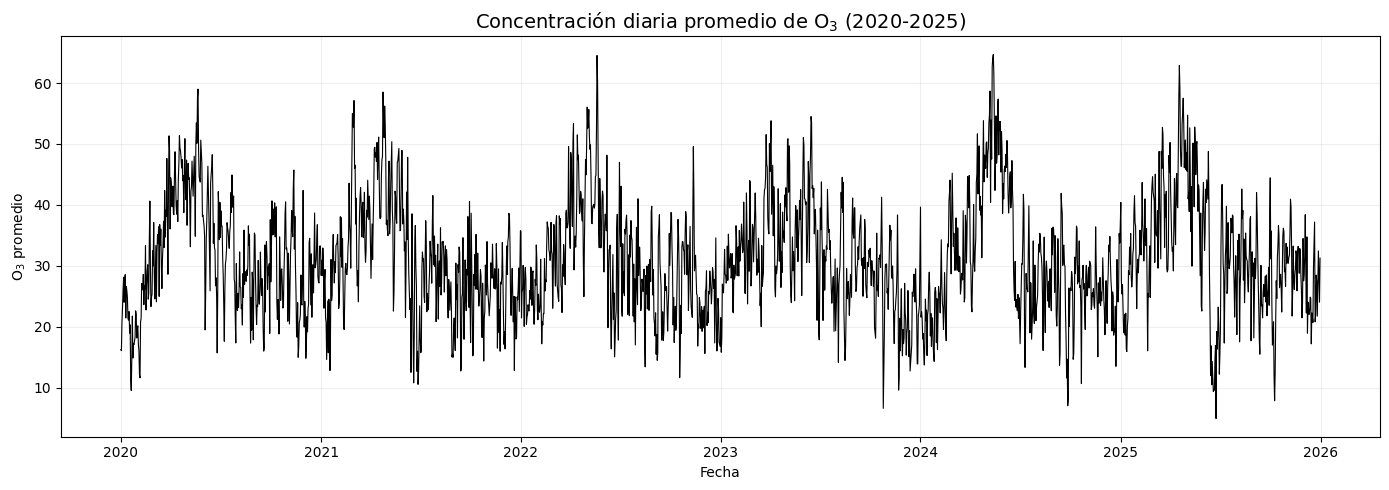

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    o3["fecha"],
    o3["o3_promedio"],
    linewidth=0.8,
    color='black'
)

ax.set_title("Concentración diaria promedio de O$_3$ (2020-2025)",fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

No se observa a simple vista una tendencia monotónica fuerte entre 2020 y 2025, pero sí parece existir una estructura que se repite cada año, con periodos de concentraciones relativamente altas y bajas. Además, hay variabilidad diaria considerable alrededor de ese patrón.

In [6]:
# Resumen descriptivo

print("Resumen de la serie diaria:")
display(o3["o3_promedio"].describe().to_frame("o3_promedio").round(2))

# Valores extremos 
fila_max = o3.loc[o3["o3_promedio"].idxmax()]
fila_min = o3.loc[o3["o3_promedio"].idxmin()]

print("\nMáximo diario:")
print(fila_max["fecha"],"|",round(fila_max["o3_promedio"], 2))

print("\nMínimo diario:")
print(fila_min["fecha"],"|",round(fila_min["o3_promedio"], 2))

Resumen de la serie diaria:


,o3_promedio
count,2192.00
mean,31.05
std,9.45
min,4.91
25%,24.52
50%,29.95
75%,36.86
max,64.69



Máximo diario:
2024-05-13 00:00:00 | 64.69

Mínimo diario:
2025-06-24 00:00:00 | 4.91


## Comparación del patrón anual

La gráfica completa permite observar la evolución de la serie a lo largo de seis años, pero no facilita comparar directamente la forma de cada año.

Para estudiar la posible **estacionalidad anual**, podemos superponer las observaciones de 2020, 2021, ..., 2025 utilizando el mismo eje calendario.

La idea consiste en representar

$$
Y_{a,d},
$$

donde:

- $a$ identifica el año;
- $d$ representa el día dentro del calendario anual.

Si existe estacionalidad anual, esperaríamos que diferentes años presenten patrones aproximadamente similares en las mismas épocas del año.

Para realizar una comparación correcta utilizaremos el mes y el día de cada observación, evitando que los años bisiestos desplacen artificialmente las fechas posteriores al 29 de febrero.

Esta visualización permitirá responder preguntas como:

- ¿las concentraciones aumentan aproximadamente en los mismos meses?
- ¿existen periodos del año sistemáticamente más bajos?
- ¿el patrón se conserva entre años?
- ¿algunos años presentan niveles particularmente diferentes?

La similitud entre años sería evidencia visual de una posible componente estacional, aunque posteriormente la estudiaremos de manera más formal.

In [9]:
# Variables de calendario

o3["anio"] = o3["fecha"].dt.year
o3["mes"] = o3["fecha"].dt.month
o3["dia"] = o3["fecha"].dt.day


# Fecha de referencia común

o3["fecha_calendario"] = pd.to_datetime(
    "2000-" + o3["fecha"].dt.strftime("%m-%d"))

o3

,fecha,o3_promedio,anio,mes,dia,fecha_calendario
0,2020-01-01,16.218750,2020,1,1,2000-01-01
1,2020-01-02,16.052083,2020,1,2,2000-01-02
2,2020-01-03,20.677083,2020,1,3,2000-01-03
3,2020-01-04,23.041667,2020,1,4,2000-01-04
4,2020-01-05,25.927083,2020,1,5,2000-01-05
...,...,...,...,...,...,...
2187,2025-12-27,27.510417,2025,12,27,2000-12-27
2188,2025-12-28,32.432292,2025,12,28,2000-12-28
2189,2025-12-29,28.312500,2025,12,29,2000-12-29
2190,2025-12-30,24.020833,2025,12,30,2000-12-30


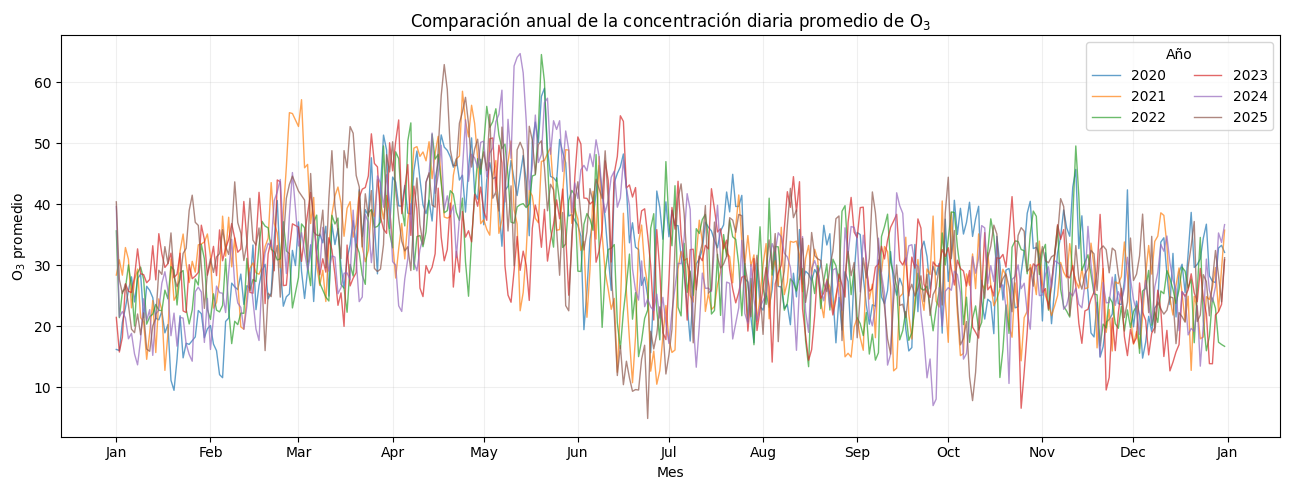

In [10]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(
    figsize=(13, 5)
)

for anio, datos_anio in o3.groupby("anio"):

    ax.plot(
        datos_anio["fecha_calendario"],
        datos_anio["o3_promedio"],
        linewidth=1,
        alpha=0.7,
        label=str(anio)
    )

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_title("Comparación anual de la concentración diaria promedio de O$_3$")
ax.set_xlabel("Mes")
ax.set_ylabel("O$_3$ promedio")
ax.legend(title="Año",ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

En varios años las concentraciones tienden a aumentar hacia marzo–mayo, mientras que durante buena parte del segundo semestre los niveles suelen ser menores. También se aprecia variabilidad importante entre años

## Perfil mensual del O$_3$

La comparación diaria entre años sugiere que existe un patrón que podría repetirse a lo largo del calendario anual.

Sin embargo, la variabilidad diaria dificulta observar claramente esa estructura.

Para reducir estas fluctuaciones calcularemos, para cada año y mes, la concentración promedio:

$$
\overline{Y}_{a,m}
=
\frac{1}{n_{a,m}}
\sum_{t\in(a,m)}Y_t,
$$

donde:

- $a$ representa el año;
- $m$ representa el mes;
- $n_{a,m}$ es el número de días disponibles en ese año y mes.

También calcularemos un perfil mensual global:

$$
\overline{Y}_m
=
\frac{1}{N_m}
\sum_{t\in m}Y_t,
$$

utilizando conjuntamente los seis años.

Si existe una componente estacional anual, esperaríamos que ciertos meses presenten sistemáticamente niveles mayores o menores de O$_3$.

El objetivo no es afirmar todavía que la estacionalidad sea estadísticamente significativa, sino identificar visualmente su forma aproximada.

In [13]:
# Promedio mensual por año

perfil_mensual_anual = (
    o3
    .groupby(["anio", "mes"],as_index=False)
    .agg(o3_promedio_mensual=("o3_promedio","mean")))


# Perfil mensual global 2020--2025

perfil_mensual_global = (
    o3
    .groupby("mes",as_index=False)
    .agg(media=("o3_promedio", "mean"),mediana=("o3_promedio", "median"),desv_std=("o3_promedio", "std"))
)

print("Perfil mensual global:")

perfil_mensual_global.round(2)

Perfil mensual global:


,mes,media,mediana,desv_std
0,1,25.08,25.46,6.12
1,2,30.25,30.43,7.45
2,3,35.70,35.55,7.15
3,4,41.63,41.88,7.97
4,5,43.33,43.61,8.61
5,6,31.62,32.81,11.33
6,7,29.88,30.35,6.87
7,8,28.32,28.38,6.14
8,9,26.79,26.52,6.87
9,10,27.76,28.43,6.99


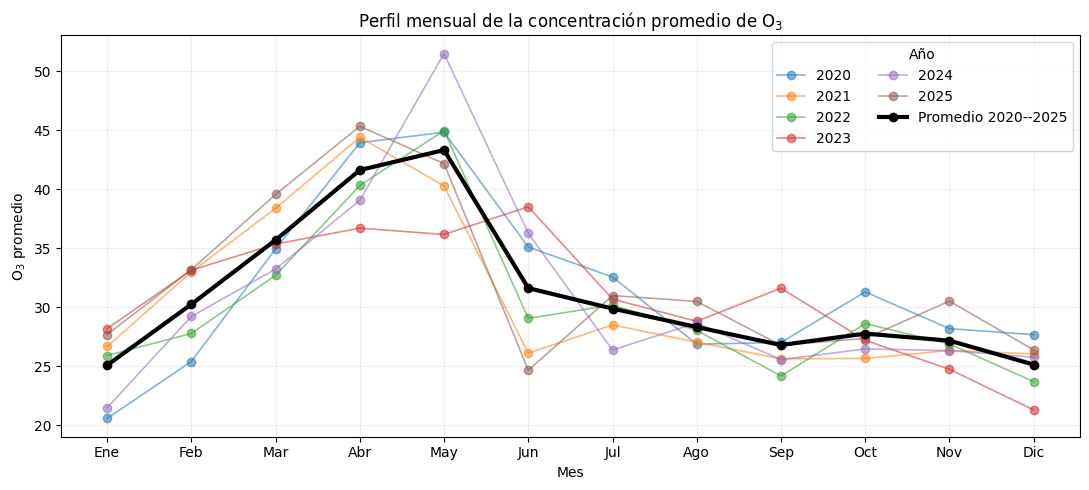

In [12]:
meses = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

fig, ax = plt.subplots(figsize=(11, 5))

# Perfil de cada año
for anio, datos in perfil_mensual_anual.groupby("anio"):

    ax.plot(
        datos["mes"],
        datos["o3_promedio_mensual"],
        marker="o",
        linewidth=1.2,
        alpha=0.55,
        label=str(anio)
    )


# Perfil promedio de los seis años
ax.plot(
    perfil_mensual_global["mes"],
    perfil_mensual_global["media"],
    marker="o",
    linewidth=3,
    label="Promedio 2020--2025",
    color='black'
)


ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_title("Perfil mensual de la concentración promedio de O$_3$")
ax.set_xlabel("Mes")
ax.set_ylabel("O$_3$ promedio")
ax.legend(title="Año",ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

El perfil mensual muestra una estructura estacional clara en la concentración diaria promedio de O$_3$.

Entre enero y mayo se observa un incremento progresivo:

$$
25.08
\rightarrow
30.25
\rightarrow
35.70
\rightarrow
41.63
\rightarrow
43.33.
$$

El máximo promedio mensual corresponde a mayo.

A partir de junio ocurre una disminución importante:

$$
43.33
\rightarrow
31.62,
$$

y durante el segundo semestre las concentraciones promedio se mantienen generalmente entre aproximadamente $25$ y $30$.

Aunque el patrón general se repite entre años, existen diferencias importantes en magnitud. Por ejemplo, mayo de 2024 presenta valores considerablemente mayores que los observados en otros años.

También cambia la variabilidad mensual. Junio presenta la mayor desviación estándar:

$$
\sigma_{\text{junio}}\approx11.33,
$$

lo que indica que durante este mes las concentraciones diarias fueron especialmente heterogéneas entre los seis años analizados.

Estos resultados proporcionan evidencia descriptiva de una posible estacionalidad anual.

## Distribución de O$_3$ por mes

El promedio mensual resume el nivel típico de cada mes, pero no muestra completamente la distribución de las observaciones diarias.

Para estudiar simultáneamente:

- mediana;
- dispersión;
- rango intercuartílico;
- asimetría;
- valores extremos;

utilizaremos diagramas de caja para cada mes del año.

Si existe una componente estacional, esperaríamos que las distribuciones de algunos meses aparezcan sistemáticamente desplazadas hacia valores mayores o menores.

Esta representación también permitirá identificar meses con mayor variabilidad.

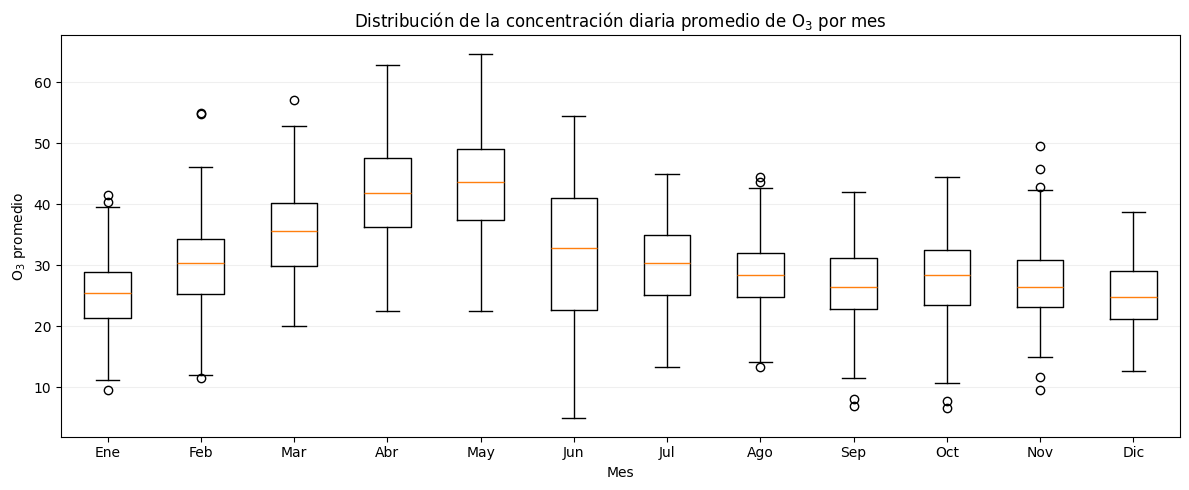

In [14]:
nombres_meses = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic"
}

o3["mes_nombre"] = o3["mes"].map(nombres_meses)

orden_meses = list(nombres_meses.values())


fig, ax = plt.subplots(figsize=(12, 5))

datos_boxplot = [
    o3.loc[o3["mes_nombre"] == mes,"o3_promedio"]
    for mes in orden_meses
]

ax.boxplot(
    datos_boxplot,
    tick_labels=orden_meses,
    showfliers=True
)

ax.set_title("Distribución de la concentración diaria promedio de O$_3$ por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("O$_3$ promedio")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

Los diagramas de caja muestran diferencias claras entre meses.

Las concentraciones diarias de O$_3$ presentan valores centrales más altos durante abril y mayo, mientras que los meses de invierno y buena parte del segundo semestre muestran niveles menores.

Junio presenta una distribución especialmente amplia, indicando una mayor variabilidad diaria durante ese mes.

Aunque existe un patrón estacional evidente, las distribuciones de distintos meses se superponen. Esto significa que la estacionalidad describe una tendencia general del calendario anual, pero no determina completamente el valor de O$_3$ de un día particular.

## Descomposición STL

Una serie temporal puede representarse conceptualmente como

$$
Y_t=
T_t
+
S_t
+
R_t,
$$

donde:

- $T_t$ es la tendencia;
- $S_t$ es la componente estacional;
- $R_t$ es el residuo o componente irregular.

La descomposición STL (*Seasonal-Trend decomposition using Loess*) permite estimar estas tres componentes de manera flexible.

Para nuestra serie diaria de O$_3$ utilizaremos un periodo anual aproximado de $365$
días.

La descomposición nos permitirá separar:

$$
\boxed{
\text{serie observada}
\rightarrow
\text{tendencia}
+
\text{estacionalidad}
+
\text{residuo}
}
$$

Esto permitirá responder tres preguntas diferentes:

1. ¿Existe un cambio gradual de largo plazo?
2. ¿Qué patrón se repite dentro del año?
3. ¿Qué parte de la variación no es explicada por las dos componentes anteriores?

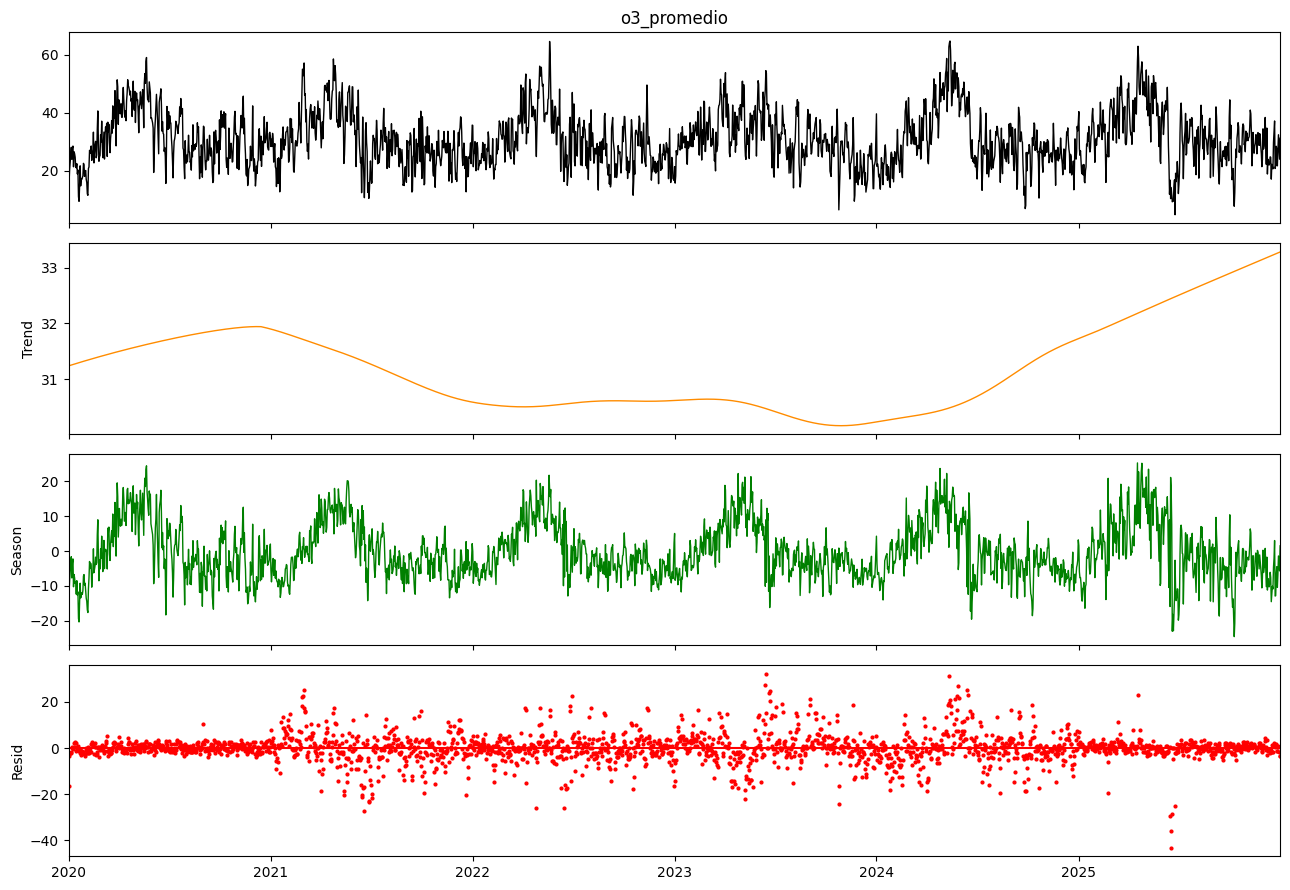

In [16]:
from statsmodels.tsa.seasonal import STL


# Serie con índice temporal

serie_o3 = o3.set_index("fecha")["o3_promedio"].asfreq("D")


# Descomposición STL

stl = STL(
    serie_o3,
    period=365,
    robust=True
)

resultado_stl = stl.fit()


# Componentes

tendencia = resultado_stl.trend
estacional = resultado_stl.seasonal
residuo = resultado_stl.resid


# Visualización

fig = resultado_stl.plot()
fig.set_size_inches(13, 9)


colores = ['black', 'darkorange', 'green', 'red']

for i, (ax, color) in enumerate(zip(fig.axes, colores)):
    for line in ax.get_lines():
        line.set_color(color)
        
        if i == 3:
            line.set_markersize(2.0)  
        else:
            line.set_linewidth(1.0)   
            
plt.tight_layout()
plt.show()


La descomposición STL permite escribir aproximadamente la serie como

$$
Y_t=
T_t
+
S_t
+
R_t.
$$

En nuestro caso se observan tres estructuras diferentes.

### Tendencia

La componente $T_t$ cambia lentamente a lo largo del periodo.

No se observa una tendencia creciente o decreciente constante durante los seis años. En cambio, la serie presenta:

- un ligero incremento inicial;
- una disminución gradual durante los años intermedios;
- un aumento nuevamente hacia 2024--2025.

Por tanto, la tendencia de largo plazo es relativamente suave en comparación con las fluctuaciones diarias y estacionales.

### Estacionalidad

La componente $S_t$ presenta un patrón que se repite aproximadamente cada año.

Esto es consistente con el análisis mensual realizado anteriormente, donde las concentraciones más altas se observaron principalmente durante primavera y los niveles más bajos durante otras épocas del año.

La repetición de esta estructura constituye evidencia de una componente estacional anual importante.

### Residuo

La componente residual

$$
R_t
=
Y_t-T_t-S_t
$$

representa la variación que no es explicada por la tendencia ni por el patrón estacional.

La mayor parte de los residuos se encuentra alrededor de cero, aunque existen episodios con desviaciones considerablemente grandes.

Estos valores pueden estar asociados con eventos particulares, condiciones meteorológicas no incluidas en la descomposición, cambios en las emisiones, errores de medición u otros factores.

Por tanto,

$$
\boxed{
\text{residuo grande}
\neq
\text{error necesariamente}
}
$$

sino simplemente una observación que no es explicada adecuadamente por las componentes de tendencia y estacionalidad.

En este ejemplo utilizamos un periodo de $365$ días como aproximación al ciclo anual.

### Cuantificación de la Importancia Relativa de las Componentes

Para medir qué tan dominantes o fuertes son la tendencia y la estacionalidad en una serie temporal descompuesta, se emplean dos indicadores basados en la varianza de las componentes:

#### 1. Fuerza de Tendencia ($F_T$)

$$F_T = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$$

* **¿Qué evalúa?** Compara la variabilidad del residuo ($R_t$) frente a la variabilidad de la serie una vez removido el componente estacional (es decir, la suma de la tendencia $T_t$ y el residuo $R_t$).


* **Lógica:** Si la variación del residuo es mínima en comparación con la tendencia, el cociente tiende a cero, haciendo que $F_T$ se acerque a 1.

#### 2. Fuerza de Estacionalidad ($F_S$)

$$F_S = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right)$$

* **¿Qué evalúa?** Compara la variabilidad del residuo ($R_t$) frente a la variabilidad de la serie sin el componente de tendencia (la suma del componente estacional $S_t$ y el residuo $R_t$).


* **Lógica:** Mide qué tan relevante y estructurado es el patrón estacional frente al ruido o error aleatorio remanente.


### Interpretación de los Resultados

* **Valores próximos a 1**: Indican que la componente analizada es **fuerte**. Esto significa que explica una parte muy significativa de la variabilidad de la serie por encima del ruido aleatorio.


* **Valores próximos a 0**: Indican que la componente es débil. La función $\max(0, \dots)$ se utiliza para garantizar que el valor de la fuerza nunca sea menor que cero.

In [17]:
# Fuerza de la tendencia y de la estacionalidad

var_residuo = np.var(residuo,ddof=1)

fuerza_tendencia = max(
    0,
    1 - var_residuo / np.var(tendencia + residuo,ddof=1))

fuerza_estacionalidad = max(
    0,
    1 - var_residuo / np.var(estacional + residuo,ddof=1))


print("Fuerza de la tendencia:")
print(f"{fuerza_tendencia:.3f}")

print("\nFuerza de la estacionalidad:")
print(f"{fuerza_estacionalidad:.3f}")

Fuerza de la tendencia:
0.012

Fuerza de la estacionalidad:
0.559


La fuerza estimada de la tendencia fue $F_T=0.012,$ mientras que la fuerza de la estacionalidad fue $F_S=0.559.$ Estos resultados indican que la serie presenta una **tendencia de largo plazo muy débil**, pero una componente estacional considerablemente más importante.

In [19]:
# Resumen de las componentes STL

resumen_stl = pd.DataFrame({
    "observada": serie_o3,
    "tendencia": tendencia,
    "estacional": estacional,
    "residuo": residuo
})

resumen_stl.describe().round(2)

,observada,tendencia,estacional,residuo
count,2192.00,2192.00,2192.00,2192.00
mean,31.05,31.20,-0.12,-0.03
std,9.45,0.80,8.04,6.29
min,4.91,30.16,-24.54,-43.10
25%,24.52,30.56,-5.78,-2.21
50%,29.95,31.02,-1.35,0.00
75%,36.86,31.77,4.84,2.15
max,64.69,33.29,25.26,32.08


La desviación estándar de la tendencia es únicamente $0.80,$ frente a una desviación estándar de $9.45$ para la serie observada.

En cambio, la componente estacional presenta una desviación estándar de $8.04,$
lo que confirma que una parte importante de las fluctuaciones del O$_3$ está asociada con el ciclo anual.

Los residuos todavía presentan una desviación estándar de $6.29,$
por lo que tendencia y estacionalidad no explican completamente la dinámica diaria.

In [20]:
# Días con residuos más extremos

residuos_extremos = (
    resumen_stl
    .assign(residuo_abs=lambda x: x["residuo"].abs())
    .sort_values("residuo_abs",ascending=False)
    .head(10)
)

print("\nDías con mayor residuo absoluto:")

residuos_extremos[["observada","tendencia","estacional","residuo"]].round(2)


Días con mayor residuo absoluto:


,observada,tendencia,estacional,residuo
fecha,,,,
2025-06-16,10.45,32.44,21.10,-43.10
2025-06-17,14.29,32.45,17.70,-35.85
2023-06-16,53.58,30.47,-8.96,32.08
2024-05-11,62.66,30.48,1.07,31.10
2025-06-14,11.95,32.44,8.93,-29.41
2025-06-18,11.56,32.45,7.59,-28.48
2023-06-14,47.83,30.47,-10.10,27.46
2021-06-19,10.77,31.32,6.89,-27.44
2024-05-28,52.01,30.54,-5.32,26.79


Algunos de los residuos absolutos más grandes se concentran en periodos de mayo y junio. Estos episodios representan observaciones que se alejan considerablemente del comportamiento esperado según la tendencia y la estacionalidad estimadas.